In [1]:
import pandas as pd

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 22px; color: red; font-weight: bold;">
    Understanding Our Data
</span>


In [2]:
# Reading training dataset
df=pd.read_csv("fraudTrain.csv")
df.info()
df.head()
print("\n Shape: ",df.shape)
print("\n Columns: ",df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1048575 non-null  int64  
 1   trans_date_trans_time  1048575 non-null  object 
 2   cc_num                 1048575 non-null  float64
 3   merchant               1048575 non-null  object 
 4   category               1048575 non-null  object 
 5   amt                    1048575 non-null  float64
 6   first                  1048575 non-null  object 
 7   last                   1048575 non-null  object 
 8   gender                 1048575 non-null  object 
 9   street                 1048575 non-null  object 
 10  city                   1048575 non-null  object 
 11  state                  1048575 non-null  object 
 12  zip                    1048575 non-null  int64  
 13  lat                    1048575 non-null  float64
 14  long              

In [3]:
df["is_fraud"].value_counts()#Imbalance

is_fraud
0    1042569
1       6006
Name: count, dtype: int64

In [4]:
df.isnull().sum() #check for missing values

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [5]:
X=df.drop("is_fraud",axis=1)
Y=df["is_fraud"]
X.nunique().sort_values(ascending=False)
X=X.drop(columns=["Unnamed: 0","trans_num","first","last","cc_num","street"])

In [6]:
#Identifying numerical and categorical variables
cat_cols=X.select_dtypes(include="object").columns
num_cols=X.select_dtypes(exclude="object").columns
print("Categorical:", len(cat_cols))
print("Numerical: ",len(num_cols))
list(cat_cols)

Categorical: 8
Numerical:  8


['trans_date_trans_time',
 'merchant',
 'category',
 'gender',
 'city',
 'state',
 'job',
 'dob']

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 22px; color: red; font-weight: bold;">
    Exploratory Data Analysis
</span>


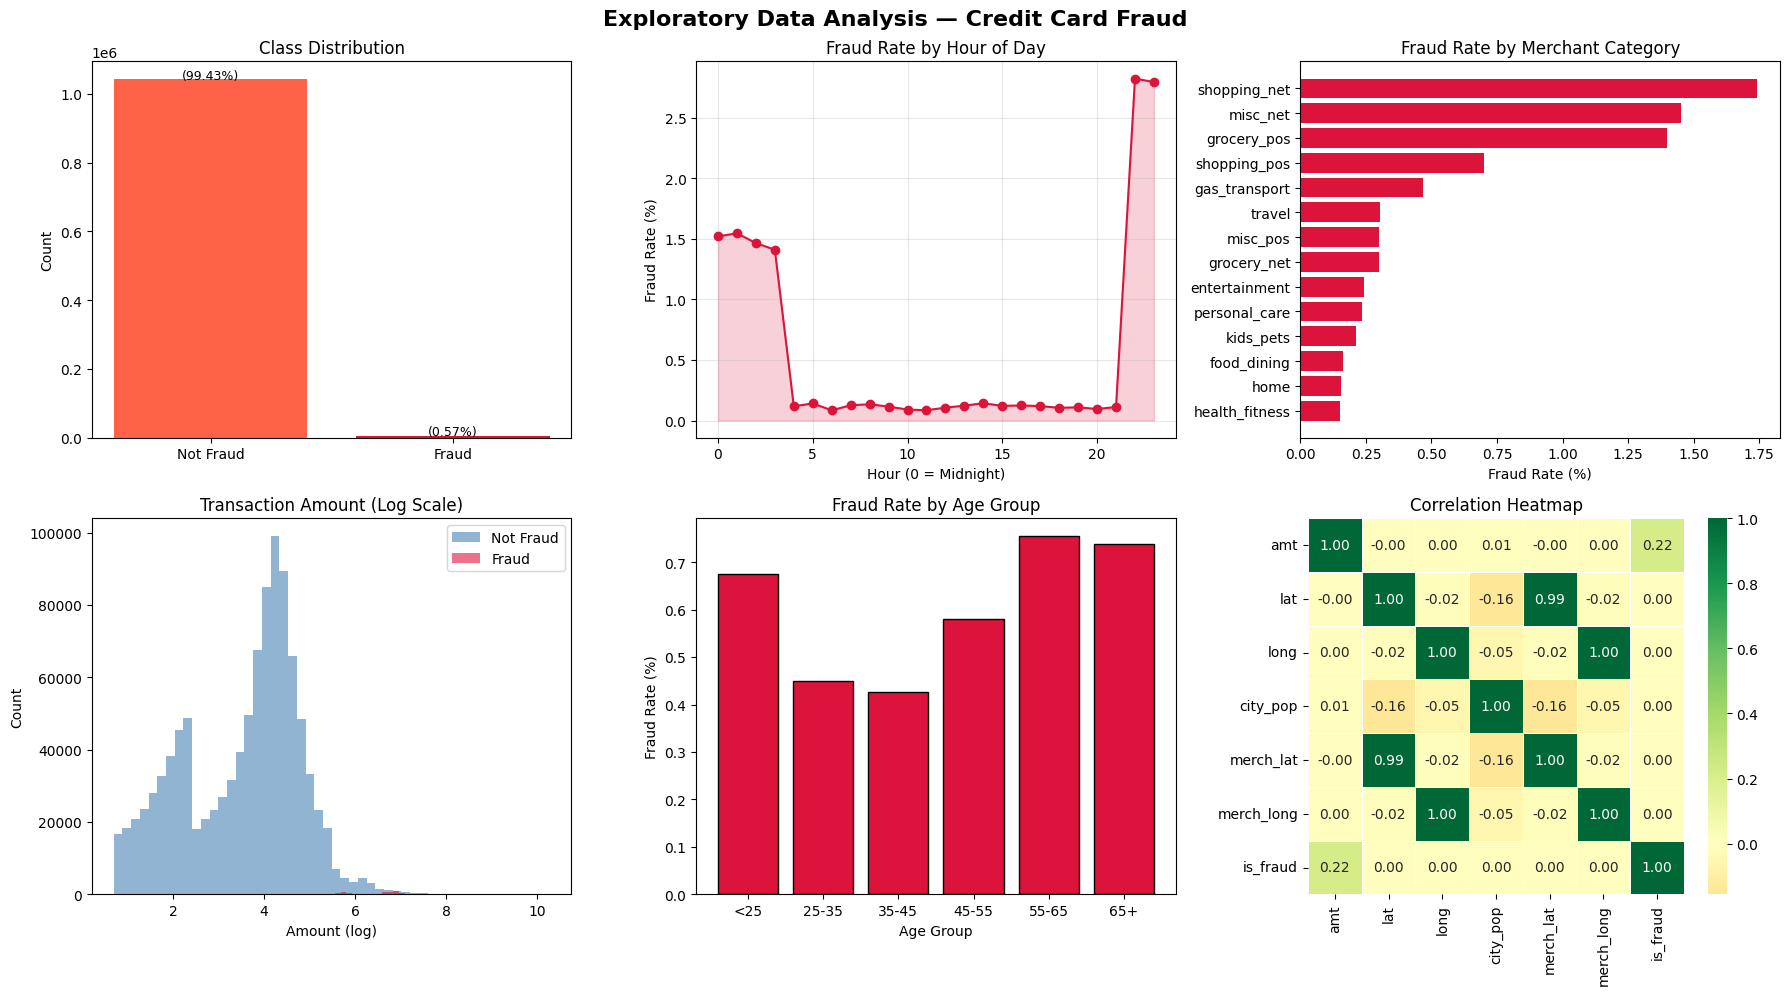

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

df = pd.read_csv("fraudTrain.csv")
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"],dayfirst=True)
df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
df["dob"] = pd.to_datetime(df["dob"],dayfirst=True)
df["age"] = df["trans_date_trans_time"].dt.year - df["dob"].dt.year
df["age_group"] = pd.cut(df["age"], bins=[0,25,35,45,55,65,100],
                          labels=["<25","25-35","35-45","45-55","55-65","65+"])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis — Credit Card Fraud", fontsize=16, fontweight="bold")

# --- 1. Class Imbalance ---
fraud_counts = df["is_fraud"].value_counts()
axes[0,0].bar(["Not Fraud", "Fraud"], fraud_counts.values, color=["tomato","crimson"])
axes[0,0].set_title("Class Distribution")
axes[0,0].set_ylabel("Count")
for i, v in enumerate(fraud_counts.values):
    axes[0,0].text(i, v+500, f"({v/len(df)*100:.2f}%)", ha="center", fontsize=9)

# --- 2. Fraud by Hour ---
hourly_fraud = df.groupby("transaction_hour")["is_fraud"].mean() * 100
axes[0,1].plot(hourly_fraud.index, hourly_fraud.values, color="crimson", marker="o")
axes[0,1].fill_between(hourly_fraud.index, hourly_fraud.values, alpha=0.2, color="crimson")
axes[0,1].set_title("Fraud Rate by Hour of Day")
axes[0,1].set_xlabel("Hour (0 = Midnight)")
axes[0,1].set_ylabel("Fraud Rate (%)")
axes[0,1].grid(alpha=0.3)

# --- 3. Fraud by Category ---
category_fraud = df.groupby("category")["is_fraud"].mean().sort_values(ascending=True) * 100
axes[0,2].barh(category_fraud.index, category_fraud.values, color="crimson")
axes[0,2].set_title("Fraud Rate by Merchant Category")
axes[0,2].set_xlabel("Fraud Rate (%)")

# --- 4. Transaction Amount ---
axes[1,0].hist(np.log1p(df[df["is_fraud"]==0]["amt"]), bins=50, alpha=0.6, color="steelblue", label="Not Fraud")
axes[1,0].hist(np.log1p(df[df["is_fraud"]==1]["amt"]), bins=50, alpha=0.6, color="crimson", label="Fraud")
axes[1,0].set_title("Transaction Amount (Log Scale)")
axes[1,0].set_xlabel("Amount (log)")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# --- 5. Fraud by Age Group ---
age_fraud = df.groupby("age_group", observed=True)["is_fraud"].mean() * 100
axes[1,1].bar(age_fraud.index.astype(str), age_fraud.values, color="crimson", edgecolor="black")
axes[1,1].set_title("Fraud Rate by Age Group")
axes[1,1].set_xlabel("Age Group")
axes[1,1].set_ylabel("Fraud Rate (%)")

# --- 6. Correlation Heatmap ---
num_features = ["amt", "lat", "long", "city_pop", "merch_lat", "merch_long", "is_fraud"]
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            square=True, linewidths=0.5, ax=axes[1,2])
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 22px; color: red; font-weight: bold;">
    Feature Engineering
</span>


In [8]:
X[["trans_date_trans_time","dob"]].head()

,trans_date_trans_time,dob
0,01-01-2019 00:00,09-03-1988
1,01-01-2019 00:00,21-06-1978
2,01-01-2019 00:00,19-01-1962
3,01-01-2019 00:01,12-01-1967
4,01-01-2019 00:03,28-03-1986


In [9]:
X["trans_date_trans_time"]=pd.to_datetime(X["trans_date_trans_time"],dayfirst=True)
X["trans_date_trans_time"].head()

0   2019-01-01 00:00:00
1   2019-01-01 00:00:00
2   2019-01-01 00:00:00
3   2019-01-01 00:01:00
4   2019-01-01 00:03:00
Name: trans_date_trans_time, dtype: datetime64[ns]

In [10]:
#Extracting transaction hour and month
X["transaction_hour"]=X["trans_date_trans_time"].dt.hour
X["transaction_month"]=X["trans_date_trans_time"].dt.month
X["transaction_day"]=X["trans_date_trans_time"].dt.day
X["transaction_weekday"]=X["trans_date_trans_time"].dt.weekday
X[["trans_date_trans_time","transaction_hour","transaction_day","transaction_month","transaction_weekday"]].head()

,trans_date_trans_time,transaction_hour,transaction_day,transaction_month,transaction_weekday
0,2019-01-01 00:00:00,0,1,1,1
1,2019-01-01 00:00:00,0,1,1,1
2,2019-01-01 00:00:00,0,1,1,1
3,2019-01-01 00:01:00,0,1,1,1
4,2019-01-01 00:03:00,0,1,1,1


In [11]:
#Extracting age
X["dob"]=pd.to_datetime(X["dob"],dayfirst=True)
X["age"]=X["trans_date_trans_time"].dt.year-X["dob"].dt.year
X["age"].head()

0    31
1    41
2    57
3    52
4    33
Name: age, dtype: int32

In [12]:
X=X.drop(columns=["trans_date_trans_time","dob"])

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 22px; color: red; font-weight: bold;">
    Data Preprocessing
</span>


In [13]:
#train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)
print(X_train.shape)
print(X_test.shape)

(838860, 19)
(209715, 19)


In [14]:
cat_cols=X.select_dtypes(include="object").columns
num_cols=X.select_dtypes(exclude="object").columns
for col in cat_cols:
    print(col,":",X[col].nunique())


merchant : 693
category : 14
gender : 2
city : 879
state : 51
job : 493


In [15]:
#Encoding Categorical Variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
preprocessor=ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "numerical",
            StandardScaler(),
            num_cols
        )
    ]
)


<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 22px; color: red; font-weight: bold;">
    Model Training
</span>


Since fraudulent transactions account for less than 1% of the dataset, accuracy is not used as the primary evaluation metric. Model         selection is based mainly on precision, recall, F1-score, and ROC-AUC.

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 19px; color: tomato; font-weight: bold;">
    Logistic Regression Baseline
</span>


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
logistic_pipeline=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LogisticRegression(max_iter=1000,class_weight="balanced"))
    ]
)
logistic_pipeline.fit(X_train,Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_pred=logistic_pipeline.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
report=classification_report(Y_test,y_pred,output_dict=True)
df_report=pd.DataFrame(report).transpose()
print("Classification Report: \n",df_report)



Classification Report: 
               precision    recall  f1-score        support
0              0.998871  0.891321  0.942037  208514.000000
1              0.041899  0.825146  0.079749    1201.000000
accuracy       0.890942  0.890942  0.890942       0.890942
macro avg      0.520385  0.858234  0.510893  209715.000000
weighted avg   0.993391  0.890942  0.937098  209715.000000


In [18]:
!pip install seaborn

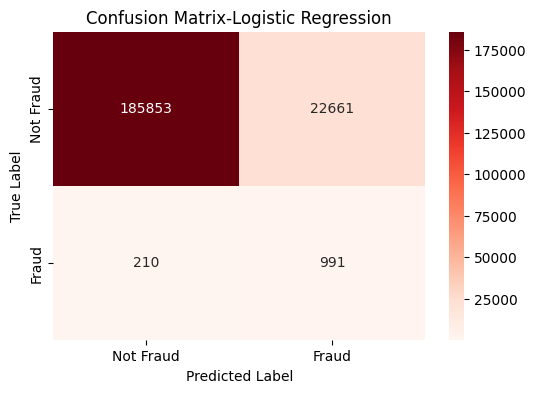

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(Y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm, #confusion matrix
    annot=True, #write number inside boxes
    fmt="d", #display as integers
    cmap="Reds",
    xticklabels=["Not Fraud","Fraud"],
    yticklabels=["Not Fraud","Fraud"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix-Logistic Regression")
plt.show()

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 19px; color: tomato; font-weight: bold;">
    Random Forest Pipeline
</span>


In [20]:
#random forest pipeline
from sklearn.ensemble import RandomForestClassifier
rf_pipeline=Pipeline(
    [
        ("preprocessor",preprocessor),
        ("model",RandomForestClassifier(
            n_estimators=50,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
        
    ]
)
rf_pipeline.fit(X_train,Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Classification Report: 
               precision    recall  f1-score        support
0              0.997646  0.999990  0.998817  208514.000000
1              0.997187  0.590341  0.741632    1201.000000
accuracy       0.997644  0.997644  0.997644       0.997644
macro avg      0.997417  0.795166  0.870224  209715.000000
weighted avg   0.997643  0.997644  0.997344  209715.000000


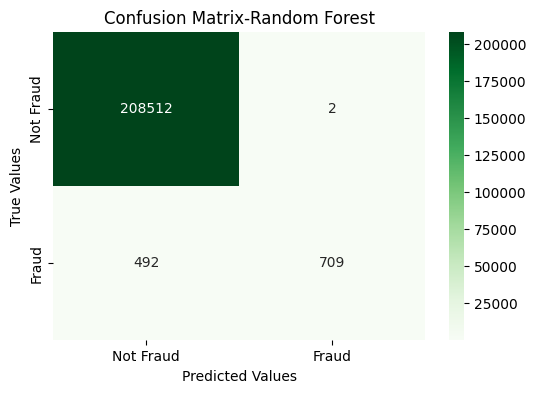

In [21]:
#Classification Report and Confusion Matrix
rf_y_pred=rf_pipeline.predict(X_test)
rf_report=classification_report(Y_test,rf_y_pred,output_dict=True)
df_rf_report=pd.DataFrame(rf_report).transpose()
print("Classification Report: \n",df_rf_report)
plt.figure(figsize=(6,4))
rf_cm=confusion_matrix(Y_test,rf_y_pred)
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Fraud","Fraud"],
    yticklabels=["Not Fraud","Fraud"],
    
)
plt.xlabel("Predicted Values")
plt.ylabel("True Values")
plt.title("Confusion Matrix-Random Forest")
plt.show()

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 19px; color: tomato; font-weight: bold;">
    XG Boost Classifier
</span>


In [22]:
#XG Boost Classifier
from xgboost import XGBClassifier
xgb_pipeline=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)
xgb_pipeline.fit(X_train,Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
!pip install xgboost


Classification Report: 
               precision    recall  f1-score        support
0              0.998793  0.999823  0.999307  208514.000000
1              0.962475  0.790175  0.867856    1201.000000
accuracy       0.998622  0.998622  0.998622       0.998622
macro avg      0.980634  0.894999  0.933581  209715.000000
weighted avg   0.998585  0.998622  0.998555  209715.000000


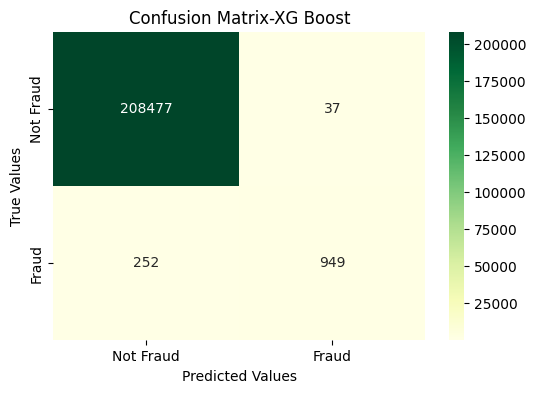

In [24]:
xgb_predict=xgb_pipeline.predict(X_test)
xgb_report=classification_report(Y_test,xgb_predict,output_dict=True)
df_xgb_report=pd.DataFrame(xgb_report).transpose()
print("Classification Report: \n",df_xgb_report)
xgb_cm=confusion_matrix(Y_test,xgb_predict)
plt.figure(figsize=(6,4))
sns.heatmap(
    xgb_cm,
    fmt="d",
    annot=True,
    cmap="YlGn",
    xticklabels=["Not Fraud","Fraud"],
    yticklabels=["Not Fraud","Fraud"]
)
plt.xlabel("Predicted Values")
plt.ylabel("True Values")
plt.title("Confusion Matrix-XG Boost")
plt.show()

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 19px; color:tomato; font-weight: bold;">
    CatBoost Classifier
</span>


In [25]:
!pip install catboost

In [26]:
from catboost import CatBoostClassifier
cb_pipeline=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",CatBoostClassifier(
            iterations=100,
            depth=6,
            learning_rate=0.1,
            random_seed=42,
            verbose=0
            
        ))
    ]
)
cb_pipeline.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Classification Report: 
               precision    recall  f1-score        support
0              0.998506  0.999832  0.999168  208514.000000
1              0.962121  0.740216  0.836706    1201.000000
accuracy       0.998345  0.998345  0.998345       0.998345
macro avg      0.980313  0.870024  0.917937  209715.000000
weighted avg   0.998297  0.998345  0.998238  209715.000000


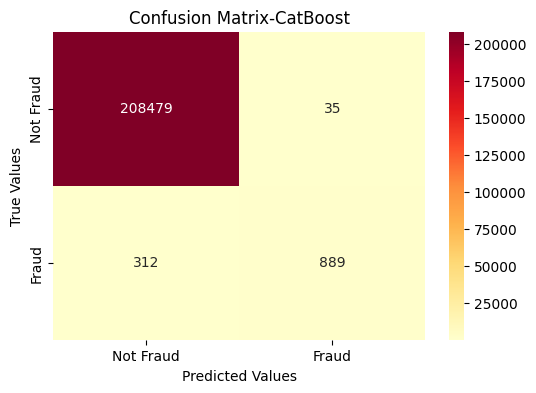

In [27]:
cb_predict=cb_pipeline.predict(X_test)
cb_report=classification_report(Y_test,cb_predict,output_dict=True)
df_cb_report=pd.DataFrame(cb_report).transpose()
print("Classification Report: \n",df_cb_report)
cb_cm=confusion_matrix(Y_test,cb_predict)
plt.figure(figsize=(6,4))
sns.heatmap(
    cb_cm,
    fmt="d",
    annot=True,
    cmap="YlOrRd",
    xticklabels=["Not Fraud","Fraud"],
    yticklabels=["Not Fraud","Fraud"]
)
plt.xlabel("Predicted Values")
plt.ylabel("True Values")
plt.title("Confusion Matrix-CatBoost")
plt.show()

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 22px; color: red; font-weight: bold;">
    Model Comparision
</span>


In [28]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,roc_auc_score
models={
    "Logistic Regression":logistic_pipeline,
    "Random Forest":rf_pipeline,
    "XGBoost":xgb_pipeline,
    "CatBoost":cb_pipeline
}
results=[]
for name,model in models.items():
    y_pred=model.predict(X_test)
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(Y_test,y_pred),
        "Precision":precision_score(Y_test,y_pred),
        "Recall":recall_score(Y_test,y_pred),
        "F1-Score":f1_score(Y_test,y_pred),
        "ROC-AUC":roc_auc_score(Y_test,model.predict_proba(X_test)[:,1])
    })
comparison_df=pd.DataFrame(results)
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8909,0.0419,0.8251,0.0797,0.9426
1,Random Forest,0.9976,0.9972,0.5903,0.7416,0.9910
2,XGBoost,0.9986,0.9625,0.7902,0.8679,0.9972
3,CatBoost,0.9983,0.9621,0.7402,0.8367,0.9921


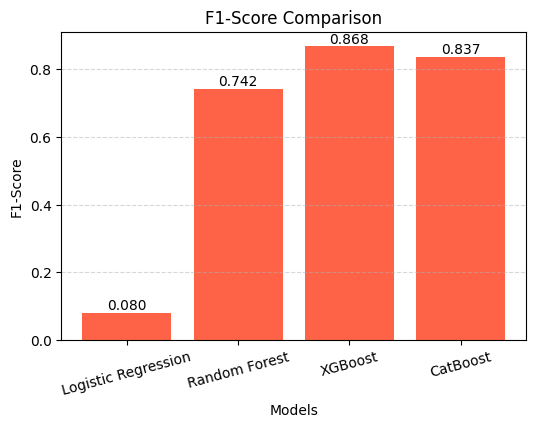

In [29]:
plt.figure(figsize=(6,4))
bars=plt.bar(comparison_df["Model"],comparison_df["F1-Score"],color="tomato")
plt.title("F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)
plt.grid(axis="y",linestyle="--",alpha=0.5)
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.01,
        f"{bar.get_height():.3f}",
        ha="center"
    )
plt.show()

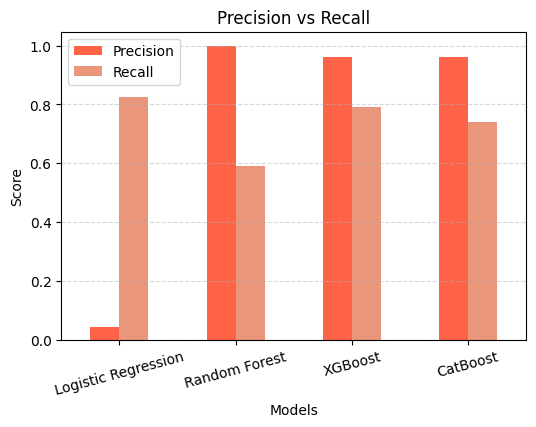

In [30]:
ax=comparison_df.set_index("Model")[["Precision","Recall"]].plot(
    kind="bar",
    figsize=(6,4),
    color=["tomato","darksalmon"])
plt.title("Precision vs Recall")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()

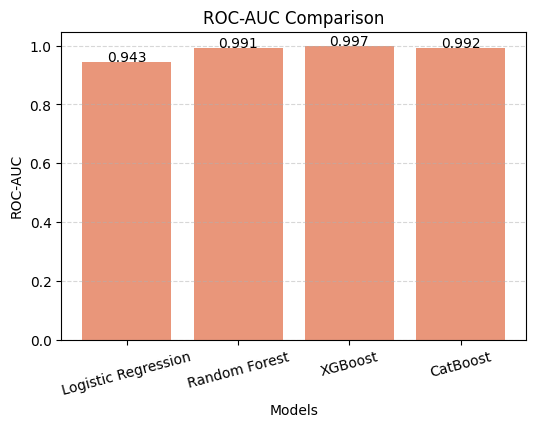

In [31]:
plt.figure(figsize=(6,4))
bars=plt.bar(comparison_df["Model"],comparison_df["ROC-AUC"],color="darksalmon")
plt.title("ROC-AUC Comparison")
plt.xlabel("Models")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=15)
plt.grid(axis="y",linestyle="--",alpha=0.5)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.003,
             f"{bar.get_height():.3f}",
             ha="center")
plt.show()

XGBoost demonstrated the best overall performance by achieving the highest F1-Score and ROC-AUC while maintaining an excellent balance between precision and recall. Although CatBoost generated fewer false positives, XGBoost successfully detected more fraudulent transactions, making it the most suitable model for this credit card fraud detection task. Therefore, XGBoost was selected as the final model for further hyperparameter tuning and optimization.

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 22px; color: red; font-weight: bold;">
    Hyperparameter Tuning
</span>


In [32]:
from sklearn.model_selection import RandomizedSearchCV
param_dist={
    "model__n_estimators":[100,200,300,500],
    "model__max_depth":[3,5,7,9],
    "model__learning_rate":[0.01,0.05,0.1,0.2],
    "model__subsample":[0.8,0.9,1.0],
    "model__colsample_bytree":[0.8,0.9,1.0]
}
random_search=RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train,Y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,"Pipeline(step...te=42, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.8, 0.9, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 9, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.9}
Best F1 Score:
0.9047747881740023
Classification Report:
               precision    recall  f1-score        support
0              0.999180  0.999856  0.999518  208514.000000
1              0.971698  0.857619  0.911101    1201.000000
accuracy       0.999042  0.999042  0.999042       0.999042
macro avg      0.985439  0.928737  0.955310  209715.000000
weighted avg   0.999023  0.999042  0.999012  209715.000000


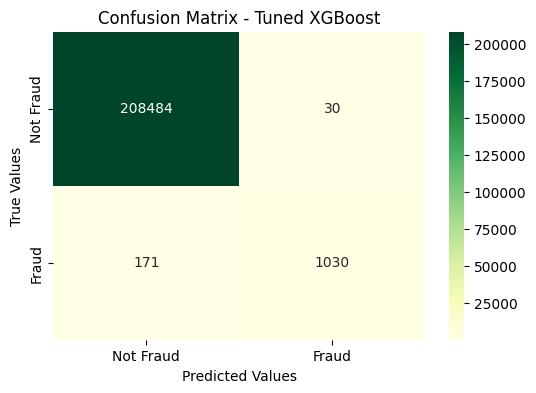

In [33]:
print("Best Parameters:")
print(random_search.best_params_)
print("Best F1 Score:")
print(random_search.best_score_)
best_pred=random_search.predict(X_test)
best_model=random_search.best_estimator_
best_report=classification_report(Y_test,best_pred,output_dict=True)
df_best_report=pd.DataFrame(best_report).transpose()
print("Classification Report:\n",df_best_report)

best_cm=confusion_matrix(Y_test,best_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=["Not Fraud","Fraud"],
    yticklabels=["Not Fraud","Fraud"]
)
plt.xlabel("Predicted Values")
plt.ylabel("True Values")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()


In [34]:
feature_names=best_model.named_steps["preprocessor"].get_feature_names_out()
importance=best_model.named_steps["model"].feature_importances_
importance_df=pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})
importance_df=importance_df.sort_values(
    by="Importance",
    ascending=False
)


In [35]:
top_features=importance_df.head(15)
print(top_features)

                                                Feature  Importance
697                   categorical__category_grocery_pos    0.164310
695                 categorical__category_gas_transport    0.109131
2132                                     numerical__amt    0.025205
2140                        numerical__transaction_hour    0.016290
701                      categorical__category_misc_net    0.016249
696                   categorical__category_grocery_net    0.014605
704                  categorical__category_shopping_net    0.012114
699                          categorical__category_home    0.010456
693                 categorical__category_entertainment    0.010402
705                  categorical__category_shopping_pos    0.009405
706                        categorical__category_travel    0.009352
1345                    categorical__city_Plantersville    0.007038
707                               categorical__gender_F    0.006581
2144                                     numeric

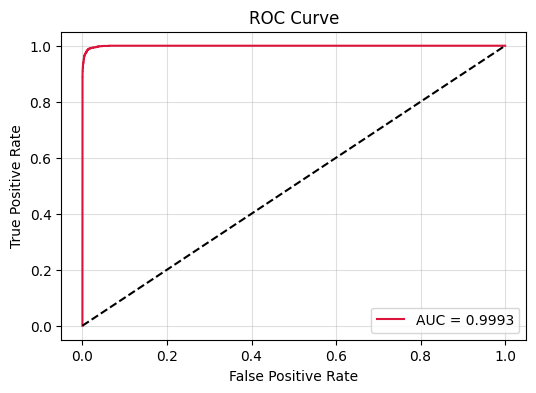

In [36]:
y_prob=best_model.predict_proba(X_test)[:,1]
from sklearn.metrics import roc_curve,roc_auc_score

fpr,tpr,thresholds=roc_curve(Y_test,y_prob)
auc_score=roc_auc_score(Y_test,y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label=f"AUC = {auc_score:.4f}",color="crimson")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

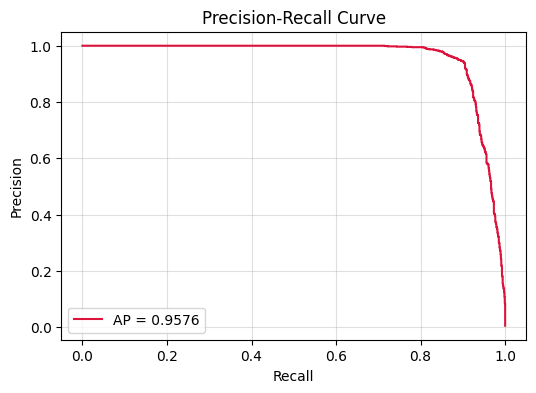

In [37]:
from sklearn.metrics import precision_recall_curve,average_precision_score
precision,recall,thresholds=precision_recall_curve(Y_test,y_prob)
ap_score=average_precision_score(Y_test,y_prob)
plt.figure(figsize=(6,4))
plt.plot(recall,precision,label=f"AP = {ap_score:.4f}",color="crimson")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

<span style="font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 22px; color: red; font-weight: bold;">
    SHAP
</span>


SHAP (SHapley Additive exPlanations) is an explainable AI technique that assigns a contribution value to each feature, showing how much it increases or decreases a model's prediction.

In [38]:
import shap
preprocessor = best_model.named_steps["preprocessor"]
xgb_model = best_model.named_steps["model"]
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_transformed)

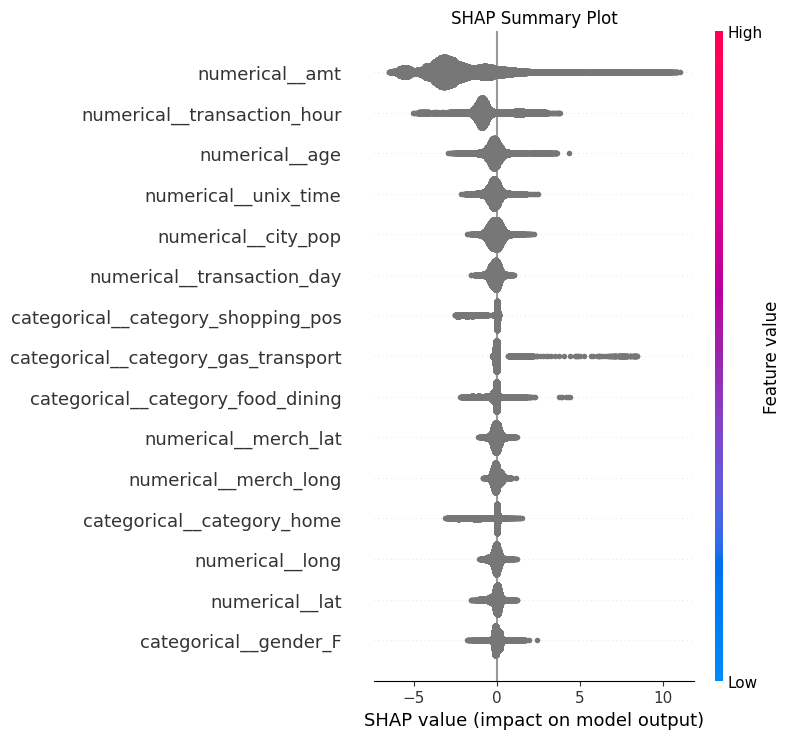

In [39]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

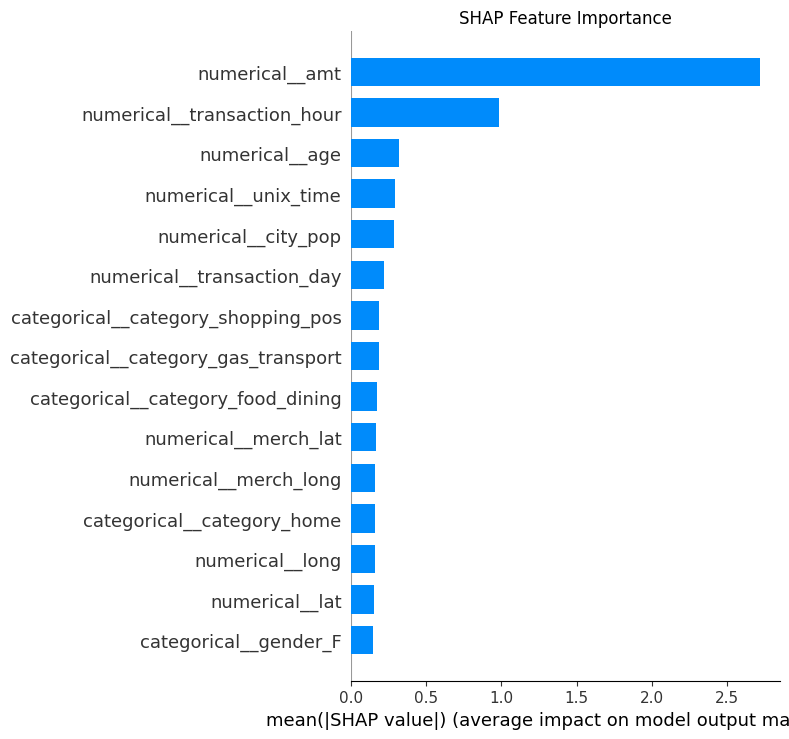

In [40]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

Explaining Transaction #269
Actual Label: Fraud
Fraud Probability: 0.9997


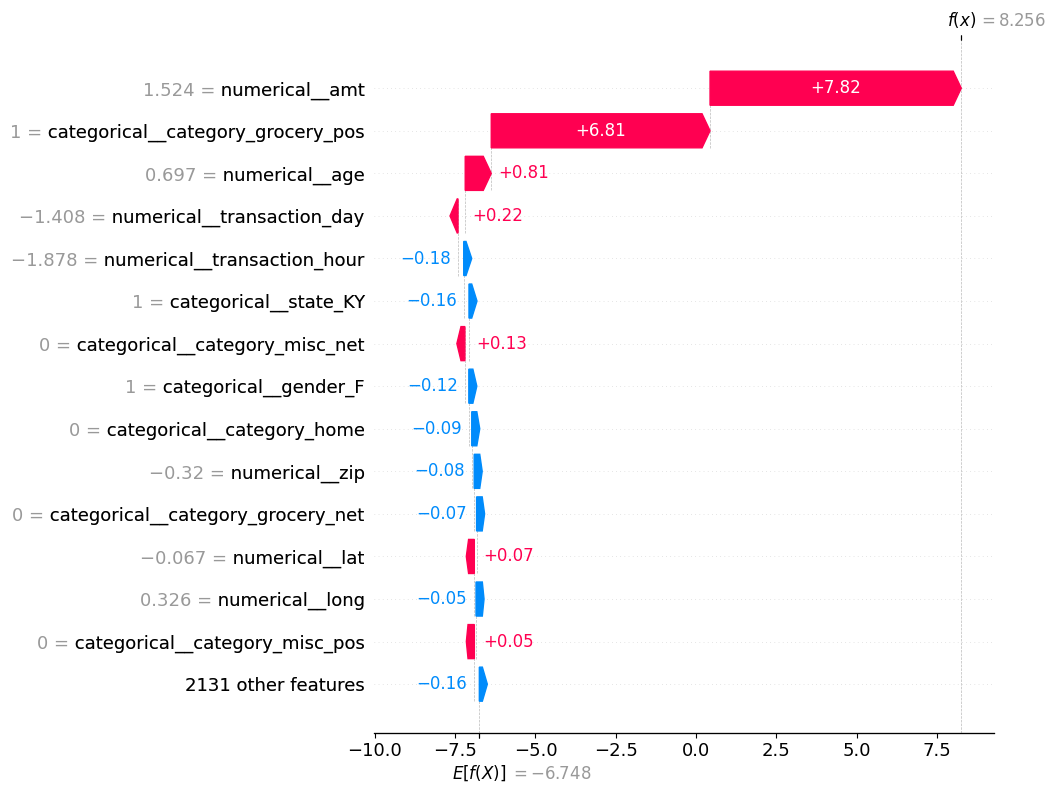

In [49]:
fraud_indices = np.where(best_pred == 1)[0]
sample_idx = fraud_indices[0]

print(f"Explaining Transaction #{sample_idx}")
print(f"Actual Label: {'Fraud' if Y_test.iloc[sample_idx] == 1 else 'Not Fraud'}")
print(f"Fraud Probability: {y_prob[sample_idx]:.4f}")
X_test_dense = X_test_transformed.toarray()
sample_explanation = shap.Explanation(
    values=shap_values.values[sample_idx],
    base_values=shap_values.base_values[sample_idx],
    data=X_test_dense[sample_idx],
    feature_names=feature_names
)



plt.figure(figsize=(10, 6))
shap.plots.waterfall(sample_explanation, max_display=15)
plt.show()

In [50]:
import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']